# Week 2 — Predictive Insight Feature Generator

## Feature Engineering & Statistical Analytics

This project transforms the sanitized customer dataset generated in Week 1 into a machine-learning-ready feature matrix.

The pipeline focuses on:

- Correlation analysis
- Correlation-driven feature engineering
- Categorical encoding
- Numerical feature scaling
- Feature matrix generation

The objective is to create meaningful, reusable, and programmatically repeatable features suitable for downstream machine learning algorithms.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Week 1 Cleaned Dataset

The sanitized dataset generated during Week 1 is used as the input for this feature engineering pipeline.

The Week 1 cleaning process removed missing values, handled invalid values, standardized data, and removed duplicate records.

This cleaned dataset will now be transformed into a machine-learning-ready feature matrix.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/saif-m7/automated-dataset-cleaning-pipeline/main/data/processed/cleaned_dataset.csv"

df = pd.read_csv(DATA_URL)

print("========== LOADING WEEK 1 CLEANED DATASET ==========")
print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

========== LOADING WEEK 1 CLEANED DATASET ==========
Dataset loaded successfully.
Rows: 15000
Columns: 30


## 2. Baseline Dataset Inspection

Before applying feature engineering transformations, the input dataset is inspected to establish its initial structure.

The baseline includes:

- Dataset dimensions
- Data types
- Missing-value count
- Sample records

These measurements will be used to compare the dataset before and after feature transformations.

In [3]:
print("========== DATASET PREVIEW ==========")
display(df.head())

print("\n========== DATA TYPES ==========")
display(df.dtypes)

print("\n========== MISSING VALUES ==========")
print(f"Total missing values: {df.isnull().sum().sum()}")

print("\n========== ORIGINAL MATRIX SHAPE ==========")
print(df.shape)

========== DATASET PREVIEW ==========


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10,2024-12-31,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,Male,35.0,Germany,Mumbai,2024-06-16,2024-05-07,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23,2024-04-28,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28,2023-05-20,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21,2024-04-07,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0



========== DATA TYPES ==========


,0
customer_id,int64
gender,object
age,float64
country,object
city,object
signup_date,object
last_purchase_date,object
acquisition_channel,object
device_type,object
subscription_type,object



========== MISSING VALUES ==========
Total missing values: 0

========== ORIGINAL MATRIX SHAPE ==========
(15000, 30)


## 3. Date Feature Engineering

Date columns contain temporal information that can be useful for machine learning. Instead of one-hot encoding every individual date, the date columns are transformed into meaningful numerical features such as year, month, and day of the week.

Customer tenure is also calculated as the number of days between signup and the last purchase.

The original date columns are removed after these features are created to prevent unnecessary dimensionality growth.

In [11]:
def create_date_features(df):
    """Convert date columns into meaningful numerical features."""

    df = df.copy()

    date_columns = [
        "signup_date",
        "last_purchase_date"
    ]

    for column in date_columns:

        df[column] = pd.to_datetime(
            df[column],
            errors="coerce"
        )

        df[f"{column}_year"] = df[column].dt.year
        df[f"{column}_month"] = df[column].dt.month
        df[f"{column}_day_of_week"] = df[column].dt.dayofweek

    df["customer_tenure_days"] = (
        df["last_purchase_date"]
        - df["signup_date"]
    ).dt.days

    df = df.drop(columns=date_columns)

    return df


df = create_date_features(df)

print("========== DATE FEATURE ENGINEERING ==========")
print(f"Shape after date feature engineering: {df.shape}")

========== DATE FEATURE ENGINEERING ==========
Shape after date feature engineering: (15000, 37)


## 4. Correlation Analysis

Pearson correlation is used to measure the linear relationship between numerical features and the target variable `churn`.

The correlation coefficient ranges from -1 to +1:

- Values close to +1 indicate a positive relationship.
- Values close to -1 indicate a negative relationship.
- Values close to 0 indicate a weak linear relationship.

The correlation results will be used to identify meaningful variables for correlation-driven feature synthesis.

In [14]:
# Select numerical columns
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

# Calculate Pearson correlation matrix
correlation_matrix = df[numerical_columns].corr(
    method="pearson"
)

# Sort correlations with churn
churn_correlation = (
    correlation_matrix["churn"]
    .sort_values(ascending=False)
)

print("========== CORRELATION WITH CHURN ==========")
display(churn_correlation)

========== CORRELATION WITH CHURN ==========


,churn
churn,1.000000
support_tickets,0.127910
support_burden,0.106530
last_purchase_date_year,0.017748
total_visits,0.013212
customer_id,0.012208
avg_session_time,0.012198
signup_date_year,0.007180
lifetime_value,0.006250
pages_per_session,0.005871


## 5. Correlation Heatmap

A Pearson correlation heatmap is generated to visually examine relationships among the numerical features.

The heatmap provides a visual representation of positive and negative correlations and supports the selection of variables for feature synthesis.

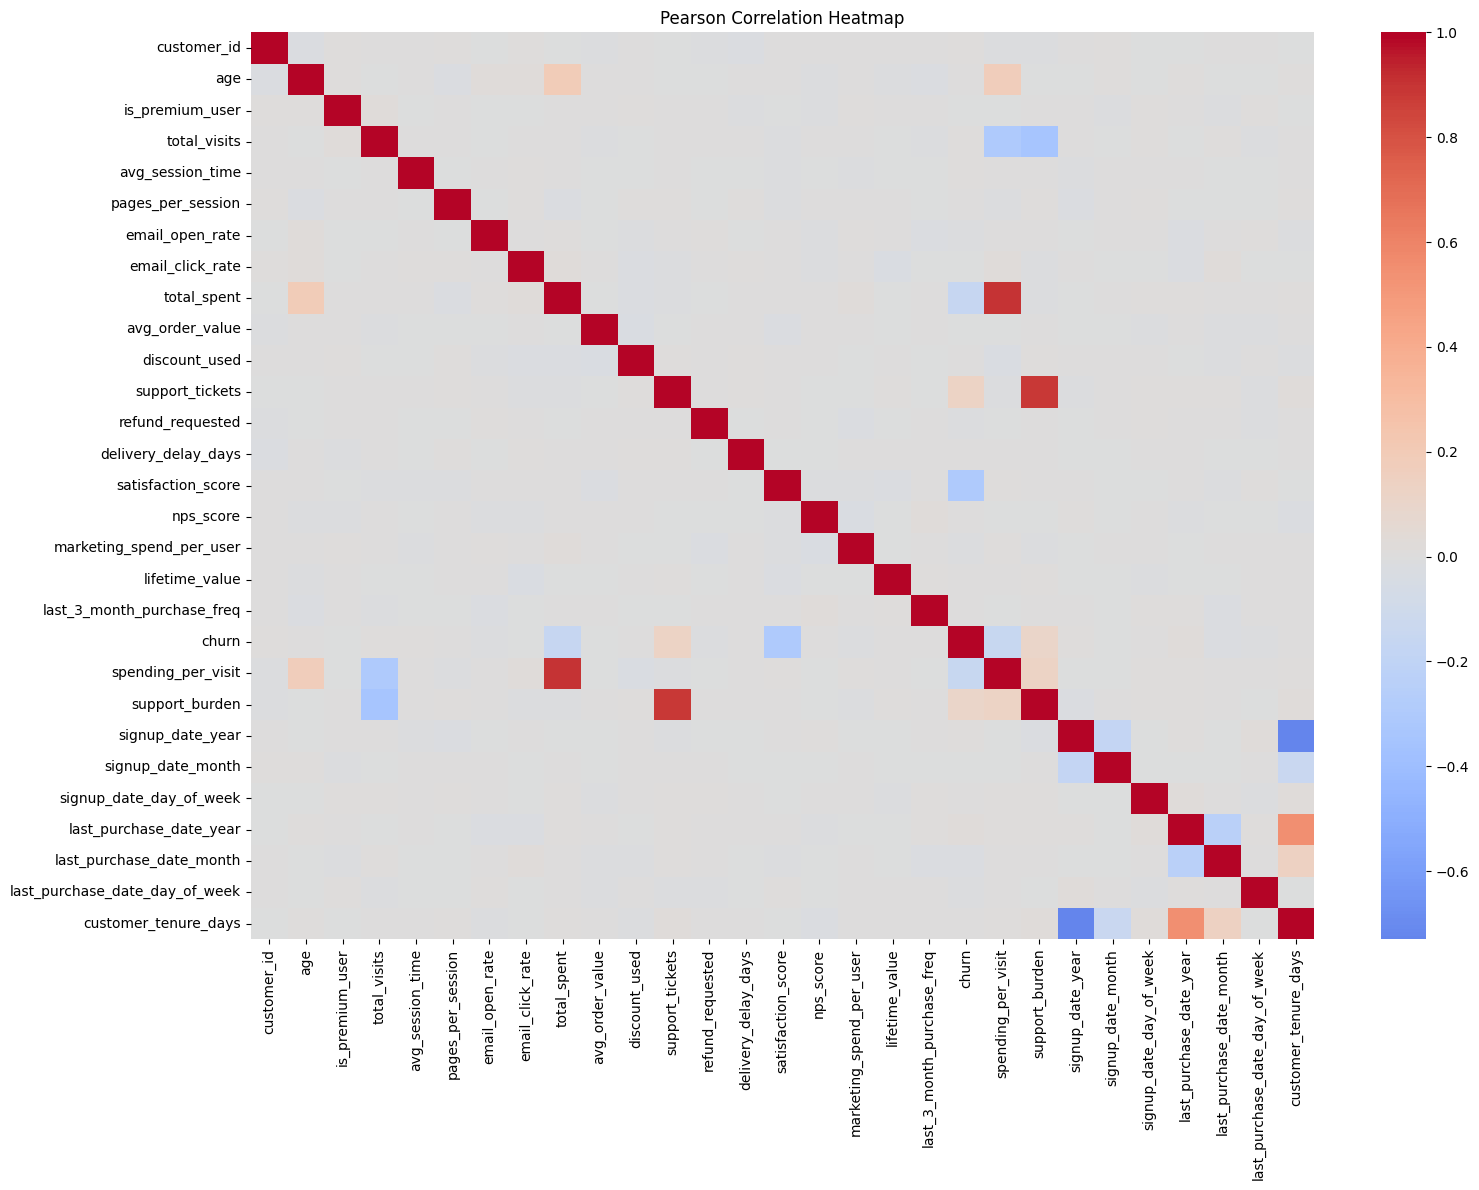

In [15]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()

plt.show()

## 6. Correlation-Driven Feature Synthesis

The correlation analysis identified `total_spent` and `support_tickets` as meaningful variables associated with customer churn.

Two ratio-based features are engineered to provide normalized behavioral signals:

### 1. Spending Per Visit

$$
\text{spending\_per\_visit} =
\frac{\text{total\_spent}}{\text{total\_visits}}
$$

This measures the customer's spending intensity relative to their number of visits.

### 2. Support Burden

$$
\text{support\_burden} =
\frac{\text{support\_tickets}}{\text{total\_visits}}
$$

This measures the number of support interactions relative to customer activity.

These features are calculated programmatically and are designed to provide additional behavioral signals for downstream machine learning models.

In [16]:
def create_engineered_features(df):
    """
    Create correlation-driven ratio features.
    """

    df = df.copy()

    # Spending intensity per customer visit
    df["spending_per_visit"] = (
        df["total_spent"]
        / df["total_visits"].replace(0, np.nan)
    )

    # Support burden relative to customer activity
    df["support_burden"] = (
        df["support_tickets"]
        / df["total_visits"].replace(0, np.nan)
    )

    # Handle any resulting missing or infinite values
    df["spending_per_visit"] = (
        df["spending_per_visit"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    df["support_burden"] = (
        df["support_burden"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    return df


df = create_engineered_features(df)

print("========== ENGINEERED FEATURES CREATED ==========")

print("New features:")
print("- spending_per_visit")
print("- support_burden")

print(f"\nDataset shape after feature synthesis: {df.shape}")

========== ENGINEERED FEATURES CREATED ==========
New features:
- spending_per_visit
- support_burden

Dataset shape after feature synthesis: (15000, 37)


## 7. Engineered Feature Validation

The correlations of the newly engineered features with the target variable `churn` are calculated to evaluate whether the synthesized features provide meaningful predictive signal.

This validation ensures that the engineered features are supported by the observed statistical relationships in the dataset.

In [17]:
engineered_features = [
    "spending_per_visit",
    "support_burden"
]

engineered_correlations = (
    df[engineered_features + ["churn"]]
    .corr(method="pearson")["churn"]
    .drop("churn")
    .sort_values(ascending=False)
)

print("========== ENGINEERED FEATURE CORRELATIONS ==========")
display(engineered_correlations)

========== ENGINEERED FEATURE CORRELATIONS ==========


,churn
support_burden,0.106530
spending_per_visit,-0.150776


## 8. Categorical Encoding

Categorical variables cannot be directly used by most machine learning algorithms, so they are converted into numerical representations.

One-hot encoding is used to transform categorical variables into binary indicator columns.

The `OneHotEncoder` from Scikit-learn is used with `handle_unknown="ignore"` so that the transformation remains reusable when new or unseen categories are encountered.

The raw date columns are not one-hot encoded because individual dates can create excessive numbers of features. Instead, meaningful date-derived features were created during feature engineering.

In [18]:
# Identify categorical columns
categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("========== CATEGORICAL FEATURES ==========")
print(categorical_columns)

# Apply One-Hot Encoding
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_data = encoder.fit_transform(
    df[categorical_columns]
)

encoded_feature_names = (
    encoder.get_feature_names_out(
        categorical_columns
    )
)

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_feature_names,
    index=df.index
)

print("\n========== ENCODING RESULTS ==========")
print(f"Original categorical columns: {len(categorical_columns)}")
print(f"Encoded feature columns: {encoded_df.shape[1]}")

print("\nEncoded data shape:")
print(encoded_df.shape)

display(encoded_df.head())

========== CATEGORICAL FEATURES ==========
['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']

========== ENCODING RESULTS ==========
Original categorical columns: 8
Encoded feature columns: 34

Encoded data shape:
(15000, 34)


,gender_Female,gender_Male,gender_Other,country_Bangladesh,country_Germany,country_India,country_UK,country_USA,city_Berlin,city_Delhi,...,subscription_type_Monthly,coupon_code_NEW20,coupon_code_NO_COUPON,coupon_code_REF10,coupon_code_SALE15,payment_method_BKash,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 9. Numerical Feature Scaling

Numerical features can have very different ranges and units. Standard scaling transforms each numerical feature using its mean and standard deviation.

The Z-score standardization formula is:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

- $x$ is the original value
- $\mu$ is the feature mean
- $\sigma$ is the feature standard deviation

`StandardScaler` from Scikit-learn is used to apply this transformation programmatically.

In [19]:
# Identify numerical features
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove target variable from input features
if "churn" in numerical_columns:
    numerical_columns.remove("churn")

# Remove customer ID because it is an identifier
if "customer_id" in numerical_columns:
    numerical_columns.remove("customer_id")

print("========== NUMERICAL FEATURES ==========")
print(numerical_columns)

# Apply StandardScaler
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df[numerical_columns]
)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=numerical_columns,
    index=df.index
)

print("\n========== SCALING RESULTS ==========")
print(f"Numerical features scaled: {len(numerical_columns)}")
print(f"Scaled data shape: {scaled_df.shape}")

display(scaled_df.head())

========== NUMERICAL FEATURES ==========
['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'spending_per_visit', 'support_burden', 'signup_date_year', 'signup_date_month', 'signup_date_day_of_week', 'last_purchase_date_year', 'last_purchase_date_month', 'last_purchase_date_day_of_week', 'customer_tenure_days']

========== SCALING RESULTS ==========
Numerical features scaled: 27
Scaled data shape: (15000, 27)


,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,...,last_3_month_purchase_freq,spending_per_visit,support_burden,signup_date_year,signup_date_month,signup_date_day_of_week,last_purchase_date_year,last_purchase_date_month,last_purchase_date_day_of_week,customer_tenure_days
0,1.775974,1.511434,-2.055435,1.966618,0.954363,0.598838,0.060605,0.082039,0.208759,-0.988994,...,1.624886,1.218378,-1.238981,-1.140662,-0.337252,-0.999904,0.580350,1.659304,-0.991273,1.899121
1,-0.116597,-0.661623,1.027358,-0.972213,0.911977,0.702251,0.820879,-0.368708,-0.469057,1.011129,...,0.930971,-0.539581,1.034073,1.380695,-0.035398,1.495198,0.580350,-0.306607,-0.991273,-0.825482
2,-1.007219,1.511434,0.770458,0.575632,-0.275837,-0.090583,1.304690,0.370219,0.716679,-0.988994,...,0.468361,0.021796,-0.759114,0.120017,0.568312,-0.500883,0.580350,-0.587452,1.498195,-0.042768
3,-0.005270,1.511434,0.256660,0.542171,-0.711834,0.288598,0.820879,-0.171260,0.470040,-0.988994,...,0.005752,-0.278726,-1.238981,1.380695,-1.544672,1.495198,-0.994405,-0.306607,1.000301,-1.402361
4,-0.784564,-0.661623,-0.770938,-0.076725,-1.079447,-1.538367,-0.630553,0.363457,-0.609837,1.011129,...,0.930971,0.564802,0.200620,0.120017,0.266457,0.497157,0.580350,-0.587452,1.498195,-0.010268


## 10. Final ML-Ready Feature Matrix

The scaled numerical features and one-hot encoded categorical features are combined into a single numerical feature matrix.

The target variable `churn` is kept separate from the input feature matrix because it represents the prediction target.

The resulting matrix contains only numerical values and can be used as input for downstream machine learning algorithms.

In [20]:
# Combine scaled numerical features and encoded categorical features
X = pd.concat(
    [scaled_df, encoded_df],
    axis=1
)

# Keep the target variable separate
y = df["churn"]

print("========== FINAL FEATURE MATRIX ==========")
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nFeature matrix data type:")
print(X.dtypes.unique())

print("\nFirst 5 rows of final feature matrix:")
display(X.head())

========== FINAL FEATURE MATRIX ==========
Feature matrix shape: (15000, 61)
Target shape: (15000,)

Feature matrix data type:
[dtype('float64')]

First 5 rows of final feature matrix:


,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,...,subscription_type_Monthly,coupon_code_NEW20,coupon_code_NO_COUPON,coupon_code_REF10,coupon_code_SALE15,payment_method_BKash,payment_method_Card,payment_method_PayPal,payment_method_SEPA,payment_method_UPI
0,1.775974,1.511434,-2.055435,1.966618,0.954363,0.598838,0.060605,0.082039,0.208759,-0.988994,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.116597,-0.661623,1.027358,-0.972213,0.911977,0.702251,0.820879,-0.368708,-0.469057,1.011129,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-1.007219,1.511434,0.770458,0.575632,-0.275837,-0.090583,1.304690,0.370219,0.716679,-0.988994,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.005270,1.511434,0.256660,0.542171,-0.711834,0.288598,0.820879,-0.171260,0.470040,-0.988994,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.784564,-0.661623,-0.770938,-0.076725,-1.079447,-1.538367,-0.630553,0.363457,-0.609837,1.011129,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 11. Transformation Shape Comparison

The transformation pipeline changes the representation of the dataset while preserving all customer records.

The original dataset contains 30 columns. Date-derived features and two correlation-driven features are added during feature engineering. Categorical variables are then one-hot encoded and numerical variables are standardized.

The final feature matrix contains only numerical values and is ready for downstream machine learning algorithms.

In [21]:
print("========== MATRIX SHAPE COMPARISON ==========")

print(f"Original dataset:              {(15000, 30)}")
print(f"After feature engineering:     {df.shape}")
print(f"Final feature matrix:          {X.shape}")

print("\n========== ROW PRESERVATION ==========")

print(f"Original rows: {15000}")
print(f"Final rows:    {X.shape[0]}")

if X.shape[0] == 15000:
    print("All rows preserved successfully.")
else:
    print("WARNING: Row count changed.")

========== MATRIX SHAPE COMPARISON ==========
Original dataset:              (15000, 30)
After feature engineering:     (15000, 37)
Final feature matrix:          (15000, 61)

========== ROW PRESERVATION ==========
Original rows: 15000
Final rows:    15000
All rows preserved successfully.


## 12. Scaling Validation

StandardScaler applies Z-score standardization to the numerical features.

After scaling, the numerical features should have a mean close to 0 and a standard deviation close to 1.

This validation confirms that the numerical features have been standardized correctly before being used by machine learning algorithms.

In [23]:
scaling_validation = pd.DataFrame({
    "mean": scaled_df.mean(),
    "standard_deviation": scaled_df.std()
})

print("========== SCALING VALIDATION ==========")
display(scaling_validation.round(4))

========== SCALING VALIDATION ==========


,mean,standard_deviation
age,-0.0,1.0
is_premium_user,-0.0,1.0
total_visits,-0.0,1.0
avg_session_time,-0.0,1.0
pages_per_session,0.0,1.0
email_open_rate,0.0,1.0
email_click_rate,-0.0,1.0
total_spent,0.0,1.0
avg_order_value,-0.0,1.0
discount_used,-0.0,1.0


## 13. Save Feature Engineering Outputs

The final feature matrix and correlation analysis results are saved as reusable project outputs.

The final feature matrix contains the scaled numerical features and one-hot encoded categorical features. The target variable `churn` is kept separate.

The correlation report and heatmap are also saved for documentation and downstream analysis.

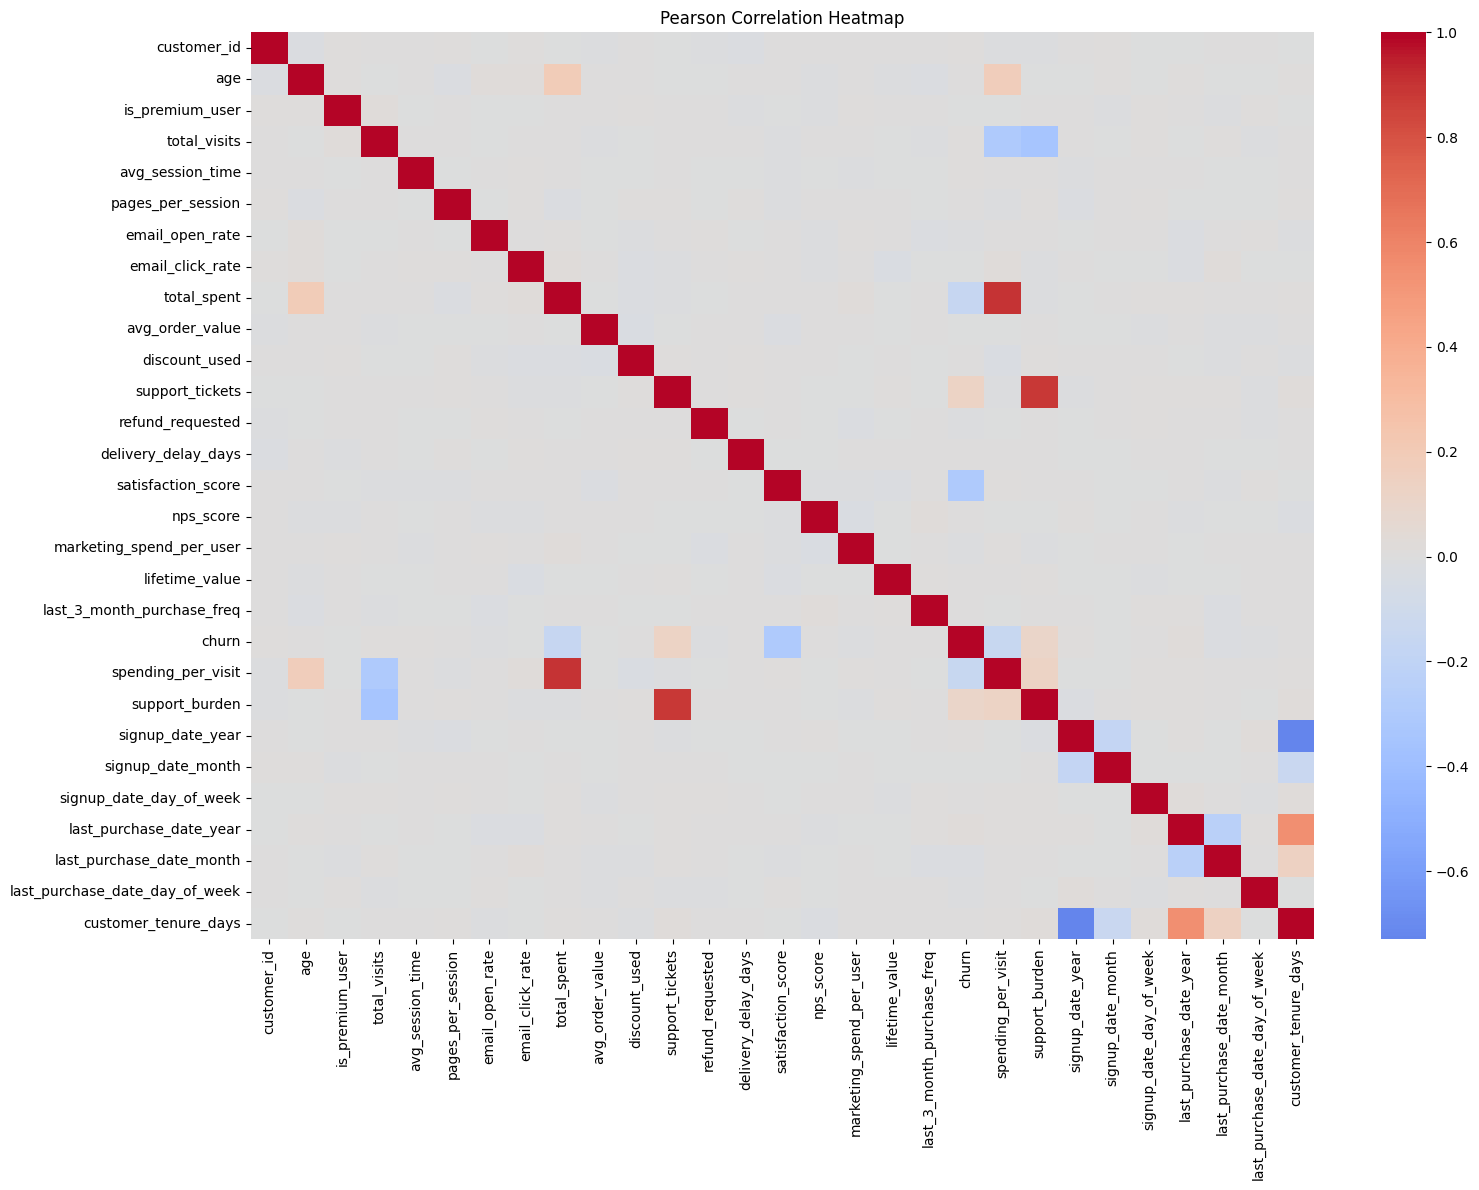

========== OUTPUTS SAVED ==========
Feature matrix:
data/feature_engineered_dataset.csv

Target:
data/target_churn.csv

Correlation report:
outputs/reports/feature_correlations.csv

Correlation heatmap:
outputs/figures/correlation_heatmap.png


In [24]:
# Create output directories
os.makedirs("outputs/reports", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("data", exist_ok=True)

# Save final feature matrix
X.to_csv(
    "data/feature_engineered_dataset.csv",
    index=False
)

# Save target variable
y.to_csv(
    "data/target_churn.csv",
    index=False
)

# Save correlation report
correlation_matrix.to_csv(
    "outputs/reports/feature_correlations.csv"
)

# Save correlation heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "outputs/figures/correlation_heatmap.png",
    dpi=300
)

plt.show()

print("========== OUTPUTS SAVED ==========")
print("Feature matrix:")
print("data/feature_engineered_dataset.csv")

print("\nTarget:")
print("data/target_churn.csv")

print("\nCorrelation report:")
print("outputs/reports/feature_correlations.csv")

print("\nCorrelation heatmap:")
print("outputs/figures/correlation_heatmap.png")

## 14. Final Pipeline Summary

The Predictive Insight Feature Generator successfully transformed the Week 1 sanitized dataset into a machine-learning-ready feature matrix.

### Transformation Results

- Original dataset: 15,000 rows × 30 columns
- After date feature engineering: 15,000 rows × 37 columns
- After correlation-driven feature synthesis: 15,000 rows × 39 columns
- Final encoded and scaled feature matrix: 15,000 rows × 61 features
- Target variable: `churn`
- Numerical scaling: StandardScaler (Z-score)
- Categorical representation: OneHotEncoder
- Engineered features: `spending_per_visit` and `support_burden`

### Engineered Feature Signals

- `spending_per_visit`: Pearson correlation with churn = -0.150776
- `support_burden`: Pearson correlation with churn = 0.106530

All 15,000 customer records were preserved throughout the transformation process.

In [25]:
print("==============================================")
print(" PREDICTIVE INSIGHT FEATURE GENERATOR")
print("             COMPLETE")
print("==============================================")

print("\nOriginal dataset:")
print("(15000, 30)")

print("\nAfter date feature engineering:")
print("(15000, 37)")

print("\nAfter correlation-driven feature synthesis:")
print("(15000, 39)")

print("\nFinal feature matrix:")
print(X.shape)

print("\nTarget:")
print(y.shape)

print("\nAll 15,000 records preserved successfully.")
print("\nWeek 2 feature engineering pipeline completed successfully.")

 PREDICTIVE INSIGHT FEATURE GENERATOR
             COMPLETE

Original dataset:
(15000, 30)

After date feature engineering:
(15000, 37)

After correlation-driven feature synthesis:
(15000, 39)

Final feature matrix:
(15000, 61)

Target:
(15000,)

All 15,000 records preserved successfully.

Week 2 feature engineering pipeline completed successfully.
